# DATA-445 In-Class Assignment 2

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 2 assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area.

## 1. (3 points) Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [1]:
import pandas as pd

house_price = pd.read_csv('Real_Estate.csv')

## 2. (3 points) Drop the `No` column.

In [ ]:
house_price = house_price.drop(columns=["No"])
house_price.head()

,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 3. (4 points) Create a scatter plot of `house_age` and `house_price_of_unit_area`. Describe the plot.

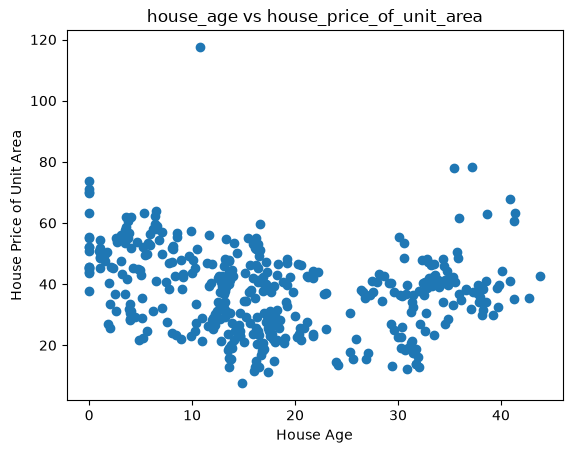

In [5]:
import matplotlib.pyplot as plt
plt.plot(house_price['house_age'],house_price['house_price_of_unit_area'], 'o')

plt.xlabel('House Age')
plt.ylabel('House Price of Unit Area')
plt.title('house_age vs house_price_of_unit_area')
plt.show()

From the scatter plot we see that there are two groups of houses which are houses in the age 0 to 25 and the age 25 to 40.
The house price associated with these two groups are different ( probably due to location and other features of the houses).

## 4. (4 points) Create a scatter plot of `distance_to_the_nearest_MRT_station` and `house_price_of_unit_area`. Describe the plot.

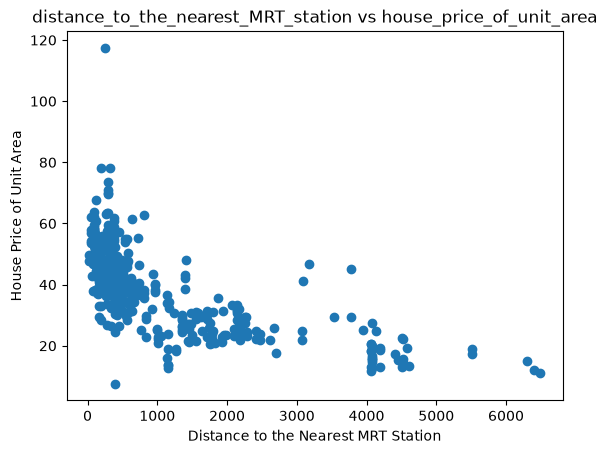

In [6]:
plt.plot(house_price['distance_to_the_nearest_MRT_station'],house_price['house_price_of_unit_area'], 'o')
plt.xlabel('Distance to the Nearest MRT Station')
plt.ylabel('House Price of Unit Area')
plt.title('distance_to_the_nearest_MRT_station vs house_price_of_unit_area')
plt.show()

From the scatter plot above we can see that as the distance goes futher out from the station the house prices decrease in correlation. (This is probably due to the station being an amenity)

## 5. (5 points) Build a linear regression model

Input variables: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude`.

Target variable: `house_price_of_unit_area`.

In [ ]:
from sklearn.linear_model import LinearRegression

X = house_price[['house_age', 'distance_to_the_nearest_MRT_station',
                 'number_of_convenience_stores', 'latitude', 'longitude']]
Y = house_price['house_price_of_unit_area']

# creating a linear regression model
model = LinearRegression()
model.fit(X, Y)





,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ -0.27, -0. , 1.16,237.77, -7.81]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['house_age','distance_to_the_nearest_MRT_station', 'number_of_convenience_stores','latitude','longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4946
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


## 6. (3 points) Using the model from part 5, predict the house price of unit area

For a house with: `house_age = 5`, `distance_to_the_nearest_MRT_station = 500`, `number_of_convenience_stores = 3`, `latitude = 24.98`, and `longitude = 121.49`.

In [10]:
new_data = pd.DataFrame({
    'house_age': [5],
    'distance_to_the_nearest_MRT_station': [500],
    'number_of_convenience_stores': [3],
    'latitude': [24.98],
    'longitude': [121.49]
})
new_data

,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude
0,5,500,3,24.98,121.49


In [11]:
predicted_price = model.predict(new_data)
print(f"The predicted house price of unit area is: {predicted_price[0]:.2f}")

The predicted house price of unit area is: 45.56
